In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow import keras
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

2025-03-02 13:03:18.564976: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data = pd.read_csv("weatherAUS.csv")
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


/var/folders/p7/d9_mnjys5ss5hl9mmyf2hsgr0000gn/T/ipykernel_62398/1568679411.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x= data["RainTomorrow"], palette= cols)


<Axes: xlabel='RainTomorrow', ylabel='count'>

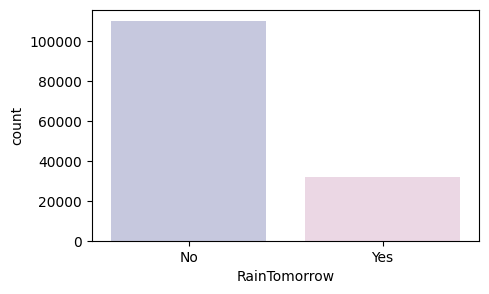

In [3]:
plt.figure(figsize=(5,3))
cols= ["#C2C4E2","#EED4E5"]
sns.countplot(x= data["RainTomorrow"], palette= cols)

<Axes: >

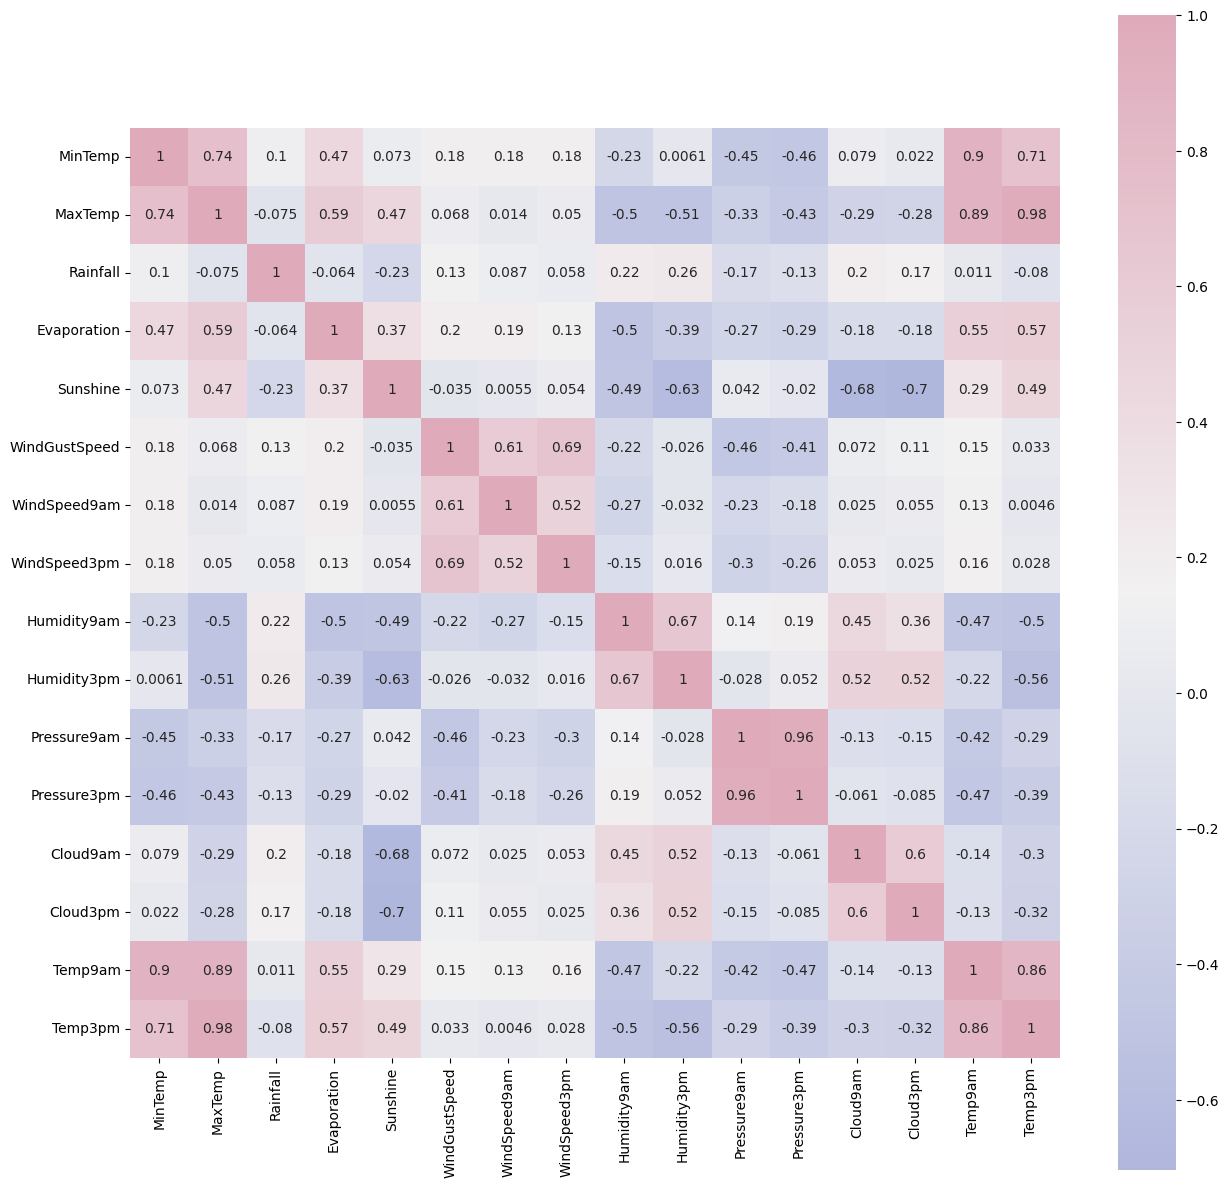

In [4]:
corrmat = data.corr(numeric_only=True)
# plt.figure(figsize=(5,3))
cmap = sns.diverging_palette(260,-10,s=50, l=75, n=6, as_cmap=True)
plt.subplots(figsize=(15,15))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [6]:
s = (data.dtypes == "object")
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)
for i in object_cols:
    print(i, data[i].isnull().sum())

Categorical variables:
['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']
Date 0
Location 0
WindGustDir 10326
WindDir9am 10566
WindDir3pm 4228
RainToday 3261
RainTomorrow 3267


In [7]:
for i in object_cols:
    data[i].fillna(data[i].mode()[0], inplace=True)

In [8]:
t = (data.dtypes == "float64")
num_cols = list(t[t].index)

print("Neumeric variables:")
print(num_cols)

Neumeric variables:
['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [9]:
for i in num_cols:
    print(i, data[i].isnull().sum())

MinTemp 1485
MaxTemp 1261
Rainfall 3261
Evaporation 62790
Sunshine 69835
WindGustSpeed 10263
WindSpeed9am 1767
WindSpeed3pm 3062
Humidity9am 2654
Humidity3pm 4507
Pressure9am 15065
Pressure3pm 15028
Cloud9am 55888
Cloud3pm 59358
Temp9am 1767
Temp3pm 3609


In [10]:
for i in num_cols:
    data[i].fillna(data[i].median(), inplace=True)
    
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  object 
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  object 
 10  WindDir3pm     145460 non-null  object 
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [11]:
label_encoder = LabelEncoder()
for i in object_cols:
    data[i] = label_encoder.fit_transform(data[i])
    # print(label_encoder.classes_)
    
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  int32  
 1   Location       145460 non-null  int32  
 2   MinTemp        145460 non-null  float64
 3   MaxTemp        145460 non-null  float64
 4   Rainfall       145460 non-null  float64
 5   Evaporation    145460 non-null  float64
 6   Sunshine       145460 non-null  float64
 7   WindGustDir    145460 non-null  int32  
 8   WindGustSpeed  145460 non-null  float64
 9   WindDir9am     145460 non-null  int32  
 10  WindDir3pm     145460 non-null  int32  
 11  WindSpeed9am   145460 non-null  float64
 12  WindSpeed3pm   145460 non-null  float64
 13  Humidity9am    145460 non-null  float64
 14  Humidity3pm    145460 non-null  float64
 15  Pressure9am    145460 non-null  float64
 16  Pressure3pm    145460 non-null  float64
 17  Cloud9am       145460 non-nul

In [12]:
features = data.drop(['RainTomorrow', 'Date'], axis=1)

target = data['RainTomorrow']

#Set up a standard scaler for the features
col_names = list(features.columns)
s_scaler = StandardScaler()
features = s_scaler.fit_transform(features)
features = pd.DataFrame(features, columns=col_names) 

features.describe().T

,count,mean,std,min,25%,50%,75%,max
Location,145460.0,7.815677e-18,1.000003,-1.672228,-0.899139,0.014511,0.857881,1.701250
MinTemp,145460.0,-4.501830e-16,1.000003,-3.250525,-0.705659,-0.030170,0.723865,3.410112
MaxTemp,145460.0,3.001220e-16,1.000003,-3.952405,-0.735852,-0.086898,0.703133,3.510563
Rainfall,145460.0,7.815677e-18,1.000003,-0.275097,-0.275097,-0.275097,-0.203581,43.945571
Evaporation,145460.0,-3.282584e-17,1.000003,-1.629472,-0.371139,-0.119472,0.006361,43.985108
Sunshine,145460.0,-5.424080e-16,1.000003,-2.897217,0.076188,0.148710,0.257494,2.360634
WindGustDir,145460.0,6.252542e-18,1.000003,-1.724209,-0.872075,0.193094,1.045228,1.471296
WindGustSpeed,145460.0,1.824961e-16,1.000003,-2.588407,-0.683048,-0.073333,0.460168,7.243246
WindDir9am,145460.0,7.190423e-17,1.000003,-1.550000,-0.885669,0.000105,0.885879,1.771653
WindDir3pm,145460.0,8.284618e-17,1.000003,-1.718521,-0.837098,0.044324,0.925747,1.586813


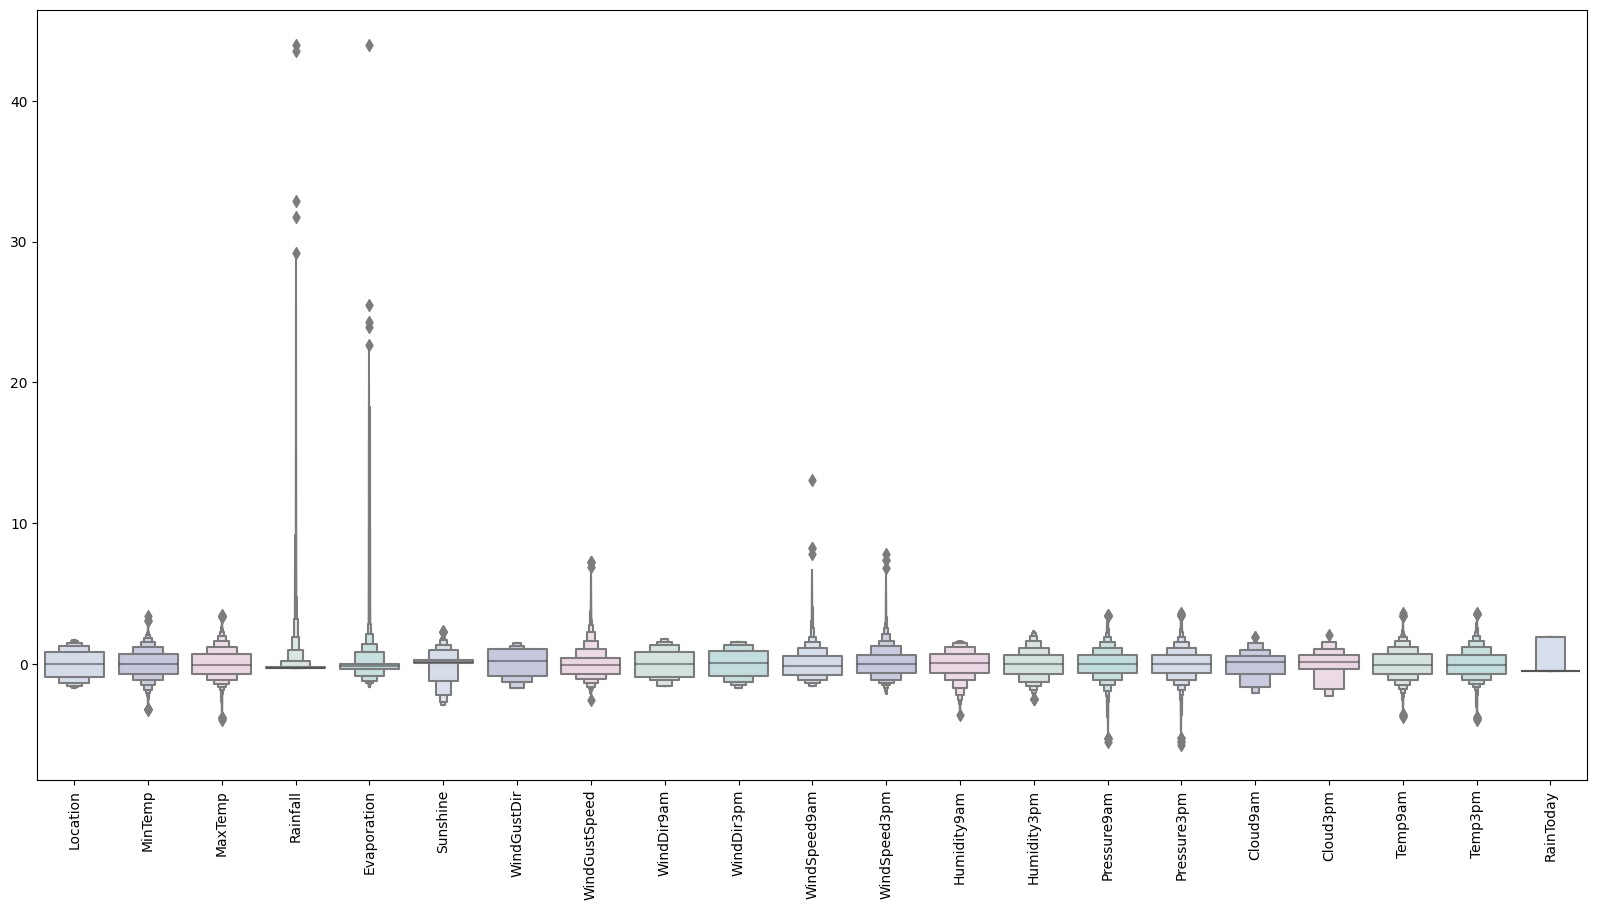

In [13]:
colours = ["#D0DBEE", "#C2C4E2", "#EED4E5", "#D1E6DC", "#BDE2E2"]
plt.figure(figsize=(20,10))
sns.boxenplot(data = features,palette = colours)
plt.xticks(rotation=90)
plt.show()

In [15]:
z_scores = np.abs((features - features.mean()) / features.std())
threshold = 3

outliers = (z_scores > threshold).any(axis=1)
df_cleaned = features[~outliers]

print(df_cleaned.shape)

(136501, 22)


In [14]:
features["RainTomorrow"] = target

#Dropping with outlier

# features = features[(features["MinTemp"]<2.3)&(features["MinTemp"]>-2.3)]
# features = features[(features["MaxTemp"]<2.3)&(features["MaxTemp"]>-2)]
# features = features[(features["Rainfall"]<4.5)]
# features = features[(features["Evaporation"]<2.8)]
# features = features[(features["Sunshine"]<2.1)]
# features = features[(features["WindGustSpeed"]<4)&(features["WindGustSpeed"]>-4)]
# features = features[(features["WindSpeed9am"]<4)]
# features = features[(features["WindSpeed3pm"]<2.5)]
# features = features[(features["Humidity9am"]>-3)]
# features = features[(features["Humidity3pm"]>-2.2)]
# features = features[(features["Pressure9am"]< 2)&(features["Pressure9am"]>-2.7)]
# features = features[(features["Pressure3pm"]< 2)&(features["Pressure3pm"]>-2.7)]
# features = features[(features["Cloud9am"]<1.8)]
# features = features[(features["Cloud3pm"]<2)]
# features = features[(features["Temp9am"]<2.3)&(features["Temp9am"]>-2)]
# features = features[(features["Temp3pm"]<2.3)&(features["Temp3pm"]>-2)]

In [16]:
X = df_cleaned.drop(["RainTomorrow"], axis=1)
y = df_cleaned["RainTomorrow"]

# Splitting test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

X.shape

(136501, 21)

In [17]:
model = keras.Sequential([
    keras.layers.Dense(units = 32, kernel_initializer = 'he_uniform', activation = 'relu', input_dim = 21),
    keras.layers.Dense(units = 32, kernel_initializer = 'he_uniform', activation = 'relu'),
    keras.layers.Dense(units = 16, kernel_initializer = 'he_uniform', activation = 'relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(units = 8, kernel_initializer = 'he_uniform', activation = 'relu'),
    keras.layers.Dropout(0.15),
    keras.layers.Dense(units = 1, kernel_initializer = 'he_uniform', activation = 'sigmoid')
    
])
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                704       
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                                 
 dense_2 (Dense)             (None, 16)                528       
                                                                 
 dropout (Dropout)           (None, 16)                0         
                                                                 
 dense_3 (Dense)             (None, 8)                 136       
                                                                 
 dropout_1 (Dropout)         (None, 8)                 0         
                                                                 
 dense_4 (Dense)             (None, 1)                 9

In [18]:
early_stopping = keras.callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

In [19]:
history = model.fit(X_train, y_train, batch_size = 32, epochs = 150, callbacks=[early_stopping], validation_split=0.2)

Epoch 1/150
2730/2730 [==============================] - 13s 4ms/step - loss: 0.4030 - accuracy: 0.8264 - val_loss: 0.3535 - val_accuracy: 0.8485
Epoch 2/150
2730/2730 [==============================] - 8s 3ms/step - loss: 0.3645 - accuracy: 0.8469 - val_loss: 0.3512 - val_accuracy: 0.8474
Epoch 3/150
2730/2730 [==============================] - 9s 3ms/step - loss: 0.3560 - accuracy: 0.8487 - val_loss: 0.3508 - val_accuracy: 0.8478
Epoch 4/150
2730/2730 [==============================] - 13s 5ms/step - loss: 0.3528 - accuracy: 0.8493 - val_loss: 0.3455 - val_accuracy: 0.8502
Epoch 5/150
2730/2730 [==============================] - 7s 3ms/step - loss: 0.3500 - accuracy: 0.8503 - val_loss: 0.3478 - val_accuracy: 0.8489
Epoch 6/150
2730/2730 [==============================] - 7s 3ms/step - loss: 0.3485 - accuracy: 0.8510 - val_loss: 0.3414 - val_accuracy: 0.8533
Epoch 7/150
2730/2730 [==============================] - 7s 3ms/step - loss: 0.3460 - accuracy: 0.8517 - val_loss: 0.3425 - val_

In [30]:
loss, acc = model.evaluate(X_test, y_test, verbose=1)
print('Test Accuracy: %.3f' % acc)

854/854 [==============================] - 2s 3ms/step - loss: 0.3506 - accuracy: 0.8490
Test Accuracy: 0.849


In [31]:
y_pred = model.predict(X_test)
y_pred1 = (y_pred > 0.5)

854/854 [==============================] - 2s 2ms/step


In [32]:
y_pred[:10]

array([[0.51716274],
       [0.08525889],
       [0.14990838],
       [0.00299168],
       [0.17432861],
       [0.09173057],
       [0.01472664],
       [0.01328311],
       [0.02105538],
       [0.06532931]], dtype=float32)

<Axes: >

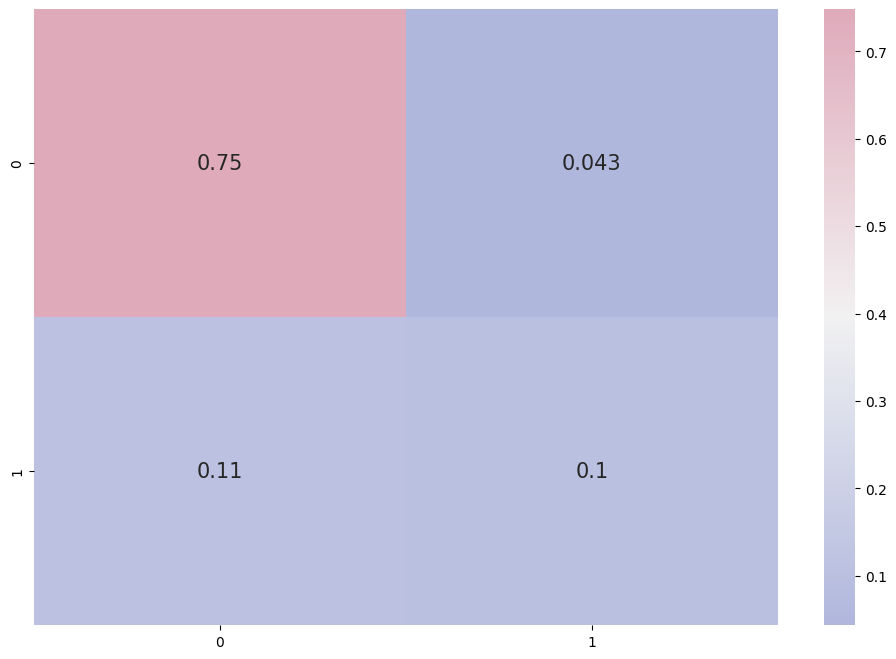

In [33]:
cmap1 = sns.diverging_palette(260,-10,s=50, l=75, n=5, as_cmap=True)
plt.subplots(figsize=(12,8))
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix/np.sum(cf_matrix), cmap = cmap1, annot = True, annot_kws = {'size':15})

In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91     21610
           1       0.75      0.42      0.54      5691

    accuracy                           0.85     27301
   macro avg       0.80      0.69      0.72     27301
weighted avg       0.84      0.85      0.83     27301



In [22]:
row = X_test[:1]
row

,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday
120729,0.506477,-0.061588,-0.580667,0.225515,-0.245306,-0.721555,1.471296,0.307739,1.771653,0.925747,...,0.037886,-0.312976,0.949946,-1.017286,-0.532733,-0.289178,1.087018,0.126045,-0.593947,1.887521


In [23]:
row = np.array(row).reshape(1, -1)
ypred = model.predict(row)

1/1 [==============================] - 0s 242ms/step


In [28]:
y_pred[:10]

array([[ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [33]:
threshold = 0.5
binary_predictions = (y_pred > threshold).astype(int)

In [35]:
binary_predictions[:10]

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0]])